<a href="https://colab.research.google.com/github/sureshs59/sureshsunuguri/blob/main/Logistic_RegAlgorithm_CityPopulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from sklearn.datasets import make_classification

# Generate a synthetic dataset for binary classification
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 rows of X:\n", X[:5])
print("First 5 values of y:\n", y[:5])

Shape of X: (200, 2)
Shape of y: (200,)
First 5 rows of X:
 [[-0.87292898  0.013042  ]
 [ 1.31293463  2.77053357]
 [ 2.34042818  2.42099601]
 [ 2.29454774 -0.40438019]
 [ 0.94410516  0.4772409 ]]
First 5 values of y:
 [1 1 1 1 1]


### 1. Understanding Logistic Regression

Logistic Regression is a statistical model used for binary classification. Despite its name, it's a classification algorithm, not a regression algorithm in the traditional sense. It predicts the probability that a given input belongs to a certain class. If the probability is above a certain threshold (commonly 0.5), it assigns the input to one class; otherwise, it assigns it to the other class.

**Key Concepts:**

*   **Sigmoid Function (Logistic Function):** At the heart of logistic regression is the sigmoid function, which squashes any real-valued number into a value between 0 and 1. This output can be interpreted as a probability.

    $$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

    Where `z` is a linear combination of input features and model coefficients: `z = b0 + b1*x1 + b2*x2 + ... + bn*xn`.

*   **Decision Boundary:** The point where the predicted probability crosses the threshold (e.g., 0.5) defines the decision boundary, separating the two classes.

*   **Cost Function:** Logistic regression uses a cost function (often called log-loss or cross-entropy loss) that penalizes incorrect classifications, guiding the model to learn optimal coefficients during training.

Let's implement a logistic regression model step-by-step.

### 2. Import Libraries and Generate a Synthetic Dataset

First, we'll import the necessary libraries and create a simple dataset for binary classification using `sklearn.datasets.make_classification`. This will allow us to clearly see how the algorithm works.

In [3]:
import pandas as pd

# Replace 'your_test_data.csv' with the actual path to your CSV file
test_df = pd.read_csv('/content/sample_data/california_housing_test.csv')

print("Shape of test_df:", test_df.shape)
print("First 5 rows of test_df:\n")
display(test_df.head(10))
display(test_df.describe())

Shape of test_df: (3000, 9)
First 5 rows of test_df:



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0
5,-119.56,36.51,37.0,1018.0,213.0,663.0,204.0,1.6635,67000.0
6,-121.43,38.63,43.0,1009.0,225.0,604.0,218.0,1.6641,67000.0
7,-120.65,35.48,19.0,2310.0,471.0,1341.0,441.0,3.2250,166900.0
8,-122.84,38.40,15.0,3080.0,617.0,1446.0,599.0,3.6696,194400.0
9,-118.02,34.08,31.0,2402.0,632.0,2830.0,603.0,2.3333,164200.0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000
mean,-119.589200,35.63539,28.845333,2599.578667,529.950667,1402.798667,489.91200,3.807272,205846.27500
std,1.994936,2.12967,12.555396,2155.593332,415.654368,1030.543012,365.42271,1.854512,113119.68747
min,-124.180000,32.56000,1.000000,6.000000,2.000000,5.000000,2.00000,0.499900,22500.00000
25%,-121.810000,33.93000,18.000000,1401.000000,291.000000,780.000000,273.00000,2.544000,121200.00000
50%,-118.485000,34.27000,29.000000,2106.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000
75%,-118.020000,37.69000,37.000000,3129.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000
max,-114.490000,41.92000,52.000000,30450.000000,5419.000000,11935.000000,4930.00000,15.000100,500001.00000


In [4]:
# Calculate the median of 'median_house_value' to use as a threshold
threshold_value = test_df['median_house_value'].median()
print(f"Median 'median_house_value' (threshold): {threshold_value}")

# Create the binary target variable 'is_expensive'
# 1 if median_house_value > threshold, 0 otherwise
test_df['is_expensive'] = (test_df['median_house_value'] > threshold_value).astype(int)

# Display the count of each class in the new target variable
print("\nDistribution of new target variable 'is_expensive':")
display(test_df['is_expensive'].value_counts())

# Display the first few rows with the new target variable
print("\nFirst 10 rows of test_df with new target variable:")
display(test_df.head(10))

Median 'median_house_value' (threshold): 177650.0

Distribution of new target variable 'is_expensive':


,count
is_expensive,
1,1500
0,1500



First 10 rows of test_df with new target variable:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,is_expensive
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0,1
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0,0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0,1
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0,1
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0,0
5,-119.56,36.51,37.0,1018.0,213.0,663.0,204.0,1.6635,67000.0,0
6,-121.43,38.63,43.0,1009.0,225.0,604.0,218.0,1.6641,67000.0,0
7,-120.65,35.48,19.0,2310.0,471.0,1341.0,441.0,3.2250,166900.0,0
8,-122.84,38.40,15.0,3080.0,617.0,1446.0,599.0,3.6696,194400.0,1
9,-118.02,34.08,31.0,2402.0,632.0,2830.0,603.0,2.3333,164200.0,0


In [6]:
# Select the specified features from test_df
X_new = test_df[['median_income', 'total_rooms']]
y_new = test_df['is_expensive']

print("Shape of X_new:", X_new.shape)
print("Shape of y_new:", y_new.shape)
print("First 5 rows of X_new:\n", X_new.head(10))
print("First 5 values of y_new:\n", y_new.head(10))

Shape of X_new: (3000, 2)
Shape of y_new: (3000,)
First 5 rows of X_new:
    median_income  total_rooms
0         6.6085       3885.0
1         3.5990       1510.0
2         5.7934       3589.0
3         6.1359         67.0
4         2.9375       1241.0
5         1.6635       1018.0
6         1.6641       1009.0
7         3.2250       2310.0
8         3.6696       3080.0
9         2.3333       2402.0
First 5 values of y_new:
 0    1
1    0
2    1
3    1
4    0
5    0
6    0
7    0
8    1
9    0
Name: is_expensive, dtype: int64


### 4b. Split the New Data into Training and Testing Sets

Now, let's split this new feature set and target variable into training and testing sets. We will use a 70/30 split, similar to our previous example.

In [8]:
from sklearn.model_selection import train_test_split

X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42, stratify=y_new)

print("X_new_train shape:", X_new_train.shape)
print("X_new_test shape:", X_new_test.shape)
print("y_new_train shape:", y_new_train.shape)
print("y_new_test shape:", y_new_test.shape)

X_new_train shape: (2400, 2)
X_new_test shape: (600, 2)
y_new_train shape: (2400,)
y_new_test shape: (600,)


### 5b. Train a New Logistic Regression Model

Now, we'll train a new Logistic Regression model using these selected features and the `is_expensive` target variable.

### 6b. Make Predictions with the New Model

We'll use the `new_model` to predict class labels and probabilities on `X_new_test`.

In [22]:
from sklearn.linear_model import LogisticRegression

# Initialize a new Logistic Regression model
new_model = LogisticRegression(random_state=42)

new_model.fit(X_new_train, y_new_train)
# Predict class labels on the new test set
y_new_pred = new_model.predict(X_new_test)

# Predict probabilities for the new test set
y_new_pred_proba = new_model.predict_proba(X_new_test)

print("First 10 predicted labels (new model):", y_new_pred[:10])
print("First 10 predicted probabilities (new model - for class 0 and 1):\n", y_new_pred_proba[:10])

First 10 predicted labels (new model): [1 1 0 0 0 1 1 1 0 1]
First 10 predicted probabilities (new model - for class 0 and 1):
 [[0.13367202 0.86632798]
 [0.08456719 0.91543281]
 [0.91898427 0.08101573]
 [0.73862142 0.26137858]
 [0.72742859 0.27257141]
 [0.28411568 0.71588432]
 [0.42444654 0.57555346]
 [0.48547838 0.51452162]
 [0.8752348  0.1247652 ]
 [0.35202237 0.64797763]]


### 7b. Evaluate the New Model

Finally, we'll evaluate the performance of our `new_model` using accuracy, confusion matrix, and a classification report for the `is_expensive` classification task.

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy for the new model
new_accuracy = accuracy_score(y_new_test, y_new_pred)
print(f"New Model Accuracy: {new_accuracy:.2f}")

# Display Confusion Matrix for the new model
new_conf_matrix = confusion_matrix(y_new_test, y_new_pred)
print("\nNew Model Confusion Matrix:\n", new_conf_matrix)

# Display Classification Report for the new model
new_class_report = classification_report(y_new_test, y_new_pred)
print("\nNew Model Classification Report:\n", new_class_report)

New Model Accuracy: 0.74

New Model Confusion Matrix:
 [[222  78]
 [ 80 220]]

New Model Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.74      0.74       300
           1       0.74      0.73      0.74       300

    accuracy                           0.74       600
   macro avg       0.74      0.74      0.74       600
weighted avg       0.74      0.74      0.74       600



### 6b. Make Predictions with the New Model

We'll use the `new_model` to predict class labels and probabilities on `X_new_test`.

In [ ]:
# Predict class labels on the new test set
y_new_pred = new_model.predict(X_new_test)

# Predict probabilities for the new test set
y_new_pred_proba = new_model.predict_proba(X_new_test)

print("First 10 predicted labels (new model):", y_new_pred[:10])
print("First 10 predicted probabilities (new model - for class 0 and 1):\n", y_new_pred_proba[:10])

### 7b. Evaluate the New Model

Finally, we'll evaluate the performance of our `new_model` using accuracy, confusion matrix, and a classification report for the `is_expensive` classification task.

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy for the new model
new_accuracy = accuracy_score(y_new_test, y_new_pred)
print(f"New Model Accuracy: {new_accuracy:.2f}")

# Display Confusion Matrix for the new model
new_conf_matrix = confusion_matrix(y_new_test, y_new_pred)
print("\nNew Model Confusion Matrix:\n", new_conf_matrix)

# Display Classification Report for the new model
new_class_report = classification_report(y_new_test, y_new_pred)
print("\nNew Model Classification Report:\n", new_class_report)

New Model Accuracy: 0.74

New Model Confusion Matrix:
 [[222  78]
 [ 80 220]]

New Model Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.74      0.74       300
           1       0.74      0.73      0.74       300

    accuracy                           0.74       600
   macro avg       0.74      0.74      0.74       600
weighted avg       0.74      0.74      0.74       600



In [19]:
from sklearn.linear_model import LogisticRegression

# Initialize a new Logistic Regression model
new_model = LogisticRegression(random_state=42)

# Train the new model using the new training data
new_model.fit(X_new_train, y_new_train)

print("New Model coefficients (weights):", new_model.coef_)
print("New Model intercept (bias):", new_model.intercept_)

New Model coefficients (weights): [[ 1.06392995e+00 -1.29793318e-05]]
New Model intercept (bias): [-3.80158664]


### 3. Visualize the Synthetic Data

Let's visualize the generated data to understand its distribution and separability.

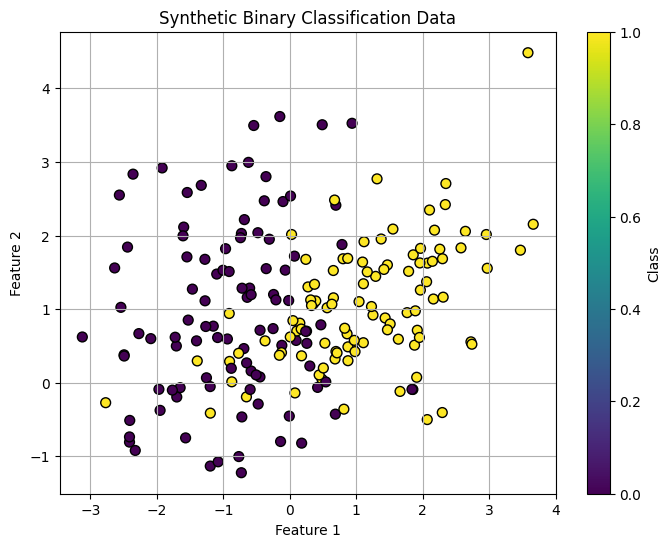

In [29]:
from matplotlib import pyplot as plt
import numpy as np
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolors='k')
plt.title('Synthetic Binary Classification Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')
plt.grid(True)
plt.show()

### 4. Split Data into Training and Testing Sets

It's crucial to split our data into training and testing sets to evaluate the model's performance on unseen data. We'll use `train_test_split` for this.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (140, 2)
X_test shape: (60, 2)
y_train shape: (140,)
y_test shape: (60,)


### 5. Train the Logistic Regression Model

Now, we'll initialize and train the `LogisticRegression` model from `sklearn.linear_model` using our training data.

In [26]:
# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42)

# Train the model using the training data
model.fit(X_train, y_train)

print("Model coefficients (weights):", model.coef_)
print("Model intercept (bias):", model.intercept_)

Model coefficients (weights): [[ 1.63007571 -0.34002837]]
Model intercept (bias): [0.11632293]


### 6. Make Predictions

Once the model is trained, we can use it to make predictions on the test set. We can predict both the class labels and the probabilities.

In [27]:
# Predict class labels on the test set
y_pred = model.predict(X_test)

# Predict probabilities for the test set
y_pred_proba = model.predict_proba(X_test)

print("First 10 predicted labels:", y_pred[:10])
print("First 10 predicted probabilities (for class 0 and 1):\n", y_pred_proba[:10])

First 10 predicted labels: [1 0 1 1 1 1 0 0 0 1]
First 10 predicted probabilities (for class 0 and 1):
 [[0.04727501 0.95272499]
 [0.76282077 0.23717923]
 [0.03996231 0.96003769]
 [0.05026887 0.94973113]
 [0.04919404 0.95080596]
 [0.04717595 0.95282405]
 [0.95538141 0.04461859]
 [0.70725302 0.29274698]
 [0.63662259 0.36337741]
 [0.43046252 0.56953748]]


### 7. Evaluate the Model

Finally, we evaluate the performance of our trained model using various metrics such as accuracy, confusion matrix, and a classification report.

In [28]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Display Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)

# Display Classification Report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", class_report)

Accuracy: 0.87

Confusion Matrix:
 [[27  3]
 [ 5 25]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87        30
           1       0.89      0.83      0.86        30

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60



### 8. Visualize the Decision Boundary (Optional)

To better understand how the model separates the classes, we can visualize its decision boundary on our 2D synthetic dataset.

/tmp/ipykernel_979/1135227116.py:7: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', marker='x', s=100, edgecolors='k', label='Test Data')


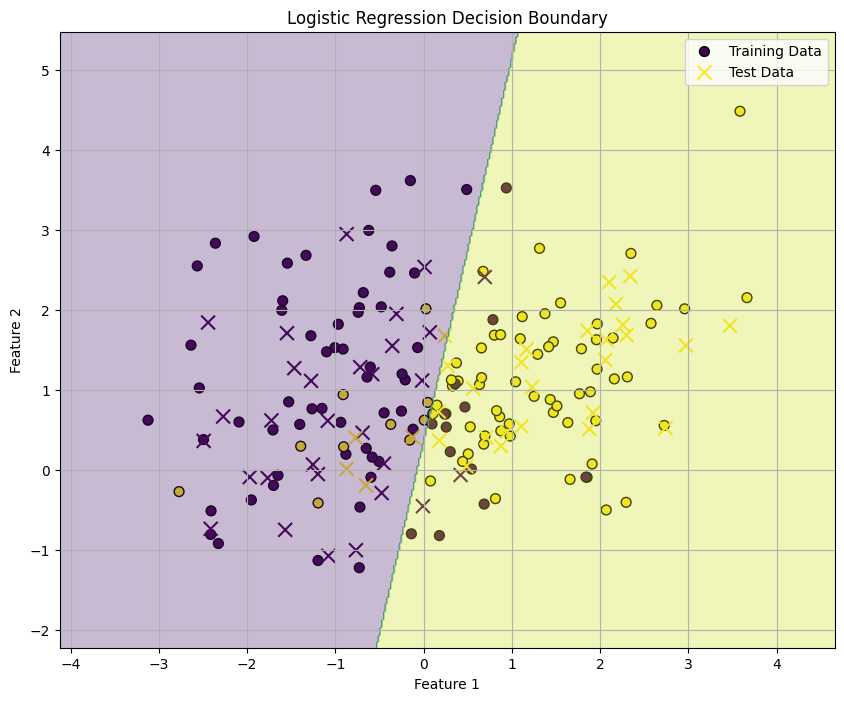

In [ ]:
plt.figure(figsize=(10, 8))

# Plot the training points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', s=50, edgecolors='k', label='Training Data')

# Plot the test points
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', marker='x', s=100, edgecolors='k', label='Test Data')

# Create a meshgrid to plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()